In [1]:
import os
import requests
import zipfile
from tqdm import tqdm

# ---------- 配置参数 ----------
DOWNLOAD_DIR = "/workspace/jupyter_app/lq/two idea"   # 存放位置（您的 Notebook 所在目录）
ZIP_FILENAME = "UAV-PDD2023.zip"                     # 压缩包名称
EXTRACT_DIR = os.path.join(DOWNLOAD_DIR, "UAV-PDD2023")  # 解压目标文件夹

# Zenodo 直接下载链接（通过 record ID 和文件名构造）
ZENODO_RECORD_ID = "8429208"
DOWNLOAD_URL = f"https://zenodo.org/records/{ZENODO_RECORD_ID}/files/{ZIP_FILENAME}?download=1"

os.makedirs(DOWNLOAD_DIR, exist_ok=True)
zip_path = os.path.join(DOWNLOAD_DIR, ZIP_FILENAME)
# ------------------------------

# 如果压缩包已存在，跳过下载
if os.path.exists(zip_path):
    print(f"✅ 文件已存在: {zip_path}，跳过下载。")
else:
    print(f"⬇️ 开始下载: {DOWNLOAD_URL}")
    # 流式下载并显示进度
    response = requests.get(DOWNLOAD_URL, stream=True)
    total_size = int(response.headers.get('content-length', 0))
    block_size = 1024 * 1024  # 1 MB 块
    with open(zip_path, 'wb') as f, tqdm(total=total_size, unit='B', unit_scale=True, desc="下载进度") as pbar:
        for chunk in response.iter_content(chunk_size=block_size):
            if chunk:
                f.write(chunk)
                pbar.update(len(chunk))
    print("✅ 下载完成。")

# 解压（如果目标目录不存在）
if not os.path.exists(EXTRACT_DIR):
    print(f"📦 解压至: {EXTRACT_DIR}")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        # 若压缩包内包含顶层文件夹，则直接解压到目标目录；若没有，则创建
        zip_ref.extractall(EXTRACT_DIR)
    print("✅ 解压完成。")
else:
    print(f"⏭️ 目标目录 {EXTRACT_DIR} 已存在，跳过解压。")

⬇️ 开始下载: https://zenodo.org/records/8429208/files/UAV-PDD2023.zip?download=1


下载进度: 100%|██████████| 2.12G/2.12G [37:28<00:00, 944kB/s]  


✅ 下载完成。
📦 解压至: /workspace/jupyter_app/lq/two idea/UAV-PDD2023
✅ 解压完成。


In [2]:
import os
import shutil
import zipfile
import random
import xml.etree.ElementTree as ET
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# ================= 路径配置 =================
BASE_DIR = "/workspace/jupyter_app/lq/two idea"          # 工作目录
ZIP_PATH = os.path.join(BASE_DIR, "UAV-PDD2023.zip")     # 原始ZIP文件
TEMP_DIR = os.path.join(BASE_DIR, "UAV_PDD_extract")     # 临时解压目录
FINAL_DIR = os.path.join(BASE_DIR, "dataset", "UAV-PDD2023")  # 最终YOLO数据集位置
TRAIN_RATIO = 0.8
RANDOM_SEED = 42
# =============================================

print("="*60)
print("🔄 开始一键重建 UAV-PDD2023 数据集 (YOLO格式)")
print("="*60)

# ---------- 1. 检查ZIP文件 ----------
if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"❌ 未找到ZIP文件: {ZIP_PATH}")

# ---------- 2. 删除旧的UAV-PDD2023文件夹（如果存在） ----------
old_path = os.path.join(BASE_DIR, "UAV-PDD2023")
if os.path.exists(old_path):
    print(f"🗑️ 删除旧目录: {old_path}")
    shutil.rmtree(old_path)

# 也删除可能残留的临时目录
if os.path.exists(TEMP_DIR):
    shutil.rmtree(TEMP_DIR)

# ---------- 3. 解压ZIP到临时目录 ----------
print(f"📦 解压 {ZIP_PATH} 到 {TEMP_DIR} ...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(TEMP_DIR)
print("✅ 解压完成")

# ---------- 4. 定位VOC原始图片和XML目录 ----------
# 解压后可能带顶层文件夹（如 UAV-PDD2023），也可能直接是文件
extract_root = TEMP_DIR
# 如果解压后只有一个子目录且名称包含 UAV，则进入
items = os.listdir(extract_root)
if len(items) == 1 and os.path.isdir(os.path.join(extract_root, items[0])):
    subdir = os.path.join(extract_root, items[0])
    # 检查该子目录下是否有典型的 VOC 子目录
    if any(os.path.isdir(os.path.join(subdir, d)) for d in ["JPEGImages", "Annotations", "images", "annotations"]):
        extract_root = subdir

print(f"📁 解压根目录: {extract_root}")

# 查找图片目录（可能叫 JPEGImages 或 images）
img_dir = None
for name in ["JPEGImages", "images", "Image", "img"]:
    candidate = os.path.join(extract_root, name)
    if os.path.isdir(candidate):
        img_dir = candidate
        break
if img_dir is None:
    # 如果根目录下直接有图片
    if any(f.lower().endswith(('.jpg','.jpeg','.png')) for f in os.listdir(extract_root)):
        img_dir = extract_root
    else:
        raise FileNotFoundError("❌ 未找到图片目录")

# 查找标注目录（可能叫 Annotations 或 annotations）
xml_dir = None
for name in ["Annotations", "annotations", "Annotation", "annotation"]:
    candidate = os.path.join(extract_root, name)
    if os.path.isdir(candidate):
        xml_dir = candidate
        break
if xml_dir is None:
    # 如果根目录下直接有 XML
    if any(f.endswith('.xml') for f in os.listdir(extract_root)):
        xml_dir = extract_root
    else:
        raise FileNotFoundError("❌ 未找到 XML 标注目录")

print(f"🖼️ 图片目录: {img_dir}")
print(f"📄 XML目录: {xml_dir}")

# ---------- 5. 获取所有配对（图片+XML同名） ----------
image_ext = {'.jpg','.jpeg','.png','.JPG','.JPEG','.PNG'}
img_files = [f for f in os.listdir(img_dir) if os.path.splitext(f)[1] in image_ext]
img_names = set(os.path.splitext(f)[0] for f in img_files)

xml_files = [f for f in os.listdir(xml_dir) if f.endswith('.xml')]
xml_names = set(os.path.splitext(f)[0] for f in xml_files)

common_names = sorted(list(img_names & xml_names))
print(f"✅ 找到 {len(common_names)} 个可配对的图片-XML文件")

if not common_names:
    raise ValueError("❌ 没有配对成功，请检查文件名是否一致")

# ---------- 6. 提取所有类别和标注框 ----------
print("🔍 扫描所有XML提取类别和标注...")
class_set = set()
all_data = {}  # 存储 {name: (img_w, img_h, [(class, xmin,ymin,xmax,ymax), ...])}
total_objects = 0

for name in tqdm(common_names, desc="解析XML"):
    xml_path = os.path.join(xml_dir, name + '.xml')
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        size = root.find('size')
        if size is None:
            print(f"⚠️ {name}.xml 缺少size，跳过")
            continue
        img_w = int(size.find('width').text)
        img_h = int(size.find('height').text)
        objects = []
        for obj in root.findall('object'):
            class_name = obj.find('name').text
            class_set.add(class_name)
            bbox = obj.find('bndbox')
            xmin = float(bbox.find('xmin').text)
            ymin = float(bbox.find('ymin').text)
            xmax = float(bbox.find('xmax').text)
            ymax = float(bbox.find('ymax').text)
            objects.append((class_name, xmin, ymin, xmax, ymax))
            total_objects += 1
        all_data[name] = (img_w, img_h, objects)
    except Exception as e:
        print(f"⚠️ 解析 {name}.xml 出错: {e}")

print(f"📊 共解析 {len(all_data)} 个文件，总标注框数: {total_objects}")

# 检查是否与官方一致（11158个框）
if total_objects != 11158:
    print(f"⚠️ 标注框总数 {total_objects} 与官方 11158 不一致，请检查")

classes = sorted(list(class_set))
class_to_id = {cls: idx for idx, cls in enumerate(classes)}
print(f"🏷️ 类别 ({len(classes)} 个): {classes}")

# ---------- 7. 划分训练/验证集 ----------
random.seed(RANDOM_SEED)
train_names, val_names = train_test_split(list(all_data.keys()), train_size=TRAIN_RATIO, random_state=RANDOM_SEED)
print(f"📊 训练集: {len(train_names)} 张, 验证集: {len(val_names)} 张")

# ---------- 8. 创建最终YOLO目录 ----------
# 先清理可能的旧目录
if os.path.exists(FINAL_DIR):
    shutil.rmtree(FINAL_DIR)

for split in ['train', 'val']:
    os.makedirs(os.path.join(FINAL_DIR, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(FINAL_DIR, 'labels', split), exist_ok=True)

print(f"📁 创建目标目录: {FINAL_DIR}")

# ---------- 9. 转换并复制文件 ----------
def convert_and_copy(names, split):
    for name in tqdm(names, desc=f"处理 {split}"):
        img_path = None
        for ext in ['.jpg','.jpeg','.png','.JPG','.JPEG','.PNG']:
            candidate = os.path.join(img_dir, name + ext)
            if os.path.exists(candidate):
                img_path = candidate
                break
        if img_path is None:
            print(f"⚠️ 找不到图片 {name}")
            continue
        
        # 复制图片
        dst_img = os.path.join(FINAL_DIR, 'images', split, os.path.basename(img_path))
        shutil.copy2(img_path, dst_img)
        
        # 生成标签
        img_w, img_h, objects = all_data[name]
        txt_path = os.path.join(FINAL_DIR, 'labels', split, name + '.txt')
        with open(txt_path, 'w') as f:
            for class_name, xmin, ymin, xmax, ymax in objects:
                class_id = class_to_id[class_name]
                x_center = (xmin + xmax) / 2.0 / img_w
                y_center = (ymin + ymax) / 2.0 / img_h
                width = (xmax - xmin) / img_w
                height = (ymax - ymin) / img_h
                # 防止溢出
                x_center = max(0, min(1, x_center))
                y_center = max(0, min(1, y_center))
                width = max(0, min(1, width))
                height = max(0, min(1, height))
                f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

convert_and_copy(train_names, 'train')
convert_and_copy(val_names, 'val')
print("✅ 图片复制和标签生成完成")

# ---------- 10. 生成 data.yaml ----------
yaml_content = f"""# YOLO 数据集配置文件 (UAV-PDD2023)
path: {FINAL_DIR}
train: images/train
val: images/val

names:
"""
for idx, name in enumerate(classes):
    yaml_content += f"  {idx}: {name}\n"

yaml_path = os.path.join(FINAL_DIR, 'data.yaml')
with open(yaml_path, 'w') as f:
    f.write(yaml_content)
print(f"📄 生成 data.yaml: {yaml_path}")

# ---------- 11. 删除VOC原始文件（清理） ----------
print("🧹 清理原始VOC文件...")
shutil.rmtree(TEMP_DIR)
print("✅ 临时解压目录已删除")
# 如果原始图片目录存在且为空目录，也可删除，但为了安全，我们只删除临时目录

print(f"\n🎉 YOLO数据集已成功生成在: {FINAL_DIR}")

# ---------- 12. 验证最终格式 ----------
print("\n" + "="*60)
print("🔬 开始验证最终YOLO数据集格式")
print("="*60)

# 统计
def count_files(dir_path, ext):
    if not os.path.isdir(dir_path):
        return 0
    return len([f for f in os.listdir(dir_path) if f.endswith(ext)])

train_img = count_files(os.path.join(FINAL_DIR, 'images', 'train'), '')
train_lbl = count_files(os.path.join(FINAL_DIR, 'labels', 'train'), '.txt')
val_img = count_files(os.path.join(FINAL_DIR, 'images', 'val'), '')
val_lbl = count_files(os.path.join(FINAL_DIR, 'labels', 'val'), '.txt')

# 统计总标注框数
total_labels = 0
for split in ['train', 'val']:
    lbl_dir = os.path.join(FINAL_DIR, 'labels', split)
    if os.path.isdir(lbl_dir):
        for f in os.listdir(lbl_dir):
            if f.endswith('.txt'):
                with open(os.path.join(lbl_dir, f), 'r') as ff:
                    total_labels += sum(1 for _ in ff)

print(f"📊 验证结果:")
print(f"  训练集图片: {train_img} 张, 标签: {train_lbl} 个")
print(f"  验证集图片: {val_img} 张, 标签: {val_lbl} 个")
print(f"  总标注框数: {total_labels} 个")

if train_img == train_lbl and val_img == val_lbl:
    print("✅ 图片与标签数量完全匹配")
else:
    print("⚠️ 图片与标签数量不匹配，请检查")

# 检查是否有空标签文件（允许，但提醒）
empty_labels = 0
for split in ['train', 'val']:
    lbl_dir = os.path.join(FINAL_DIR, 'labels', split)
    if os.path.isdir(lbl_dir):
        for f in os.listdir(lbl_dir):
            if f.endswith('.txt') and os.path.getsize(os.path.join(lbl_dir, f)) == 0:
                empty_labels += 1
if empty_labels > 0:
    print(f"⚠️ 存在 {empty_labels} 个空标签文件（可能目标稀少，属正常）")

print("\n📌 data.yaml 内容:")
print(yaml_content)
print("\n✅ 全部完成！您现在可以使用该数据集进行YOLO训练。")

🔄 开始一键重建 UAV-PDD2023 数据集 (YOLO格式)
🗑️ 删除旧目录: /workspace/jupyter_app/lq/two idea/UAV-PDD2023
📦 解压 /workspace/jupyter_app/lq/two idea/UAV-PDD2023.zip 到 /workspace/jupyter_app/lq/two idea/UAV_PDD_extract ...
✅ 解压完成
📁 解压根目录: /workspace/jupyter_app/lq/two idea/UAV_PDD_extract
🖼️ 图片目录: /workspace/jupyter_app/lq/two idea/UAV_PDD_extract/JPEGImages
📄 XML目录: /workspace/jupyter_app/lq/two idea/UAV_PDD_extract/Annotations
✅ 找到 2440 个可配对的图片-XML文件
🔍 扫描所有XML提取类别和标注...


解析XML: 100%|██████████| 2440/2440 [00:00<00:00, 6528.56it/s]


📊 共解析 2440 个文件，总标注框数: 11158
🏷️ 类别 (6 个): ['Alligator crack', 'Longitudinal crack', 'Oblique crack', 'Pothole', 'Repair', 'Transverse crack']
📊 训练集: 1952 张, 验证集: 488 张
📁 创建目标目录: /workspace/jupyter_app/lq/two idea/dataset/UAV-PDD2023


处理 val: 100%|██████████| 488/488 [00:00<00:00, 916.60it/s] 


✅ 图片复制和标签生成完成
📄 生成 data.yaml: /workspace/jupyter_app/lq/two idea/dataset/UAV-PDD2023/data.yaml
🧹 清理原始VOC文件...
✅ 临时解压目录已删除

🎉 YOLO数据集已成功生成在: /workspace/jupyter_app/lq/two idea/dataset/UAV-PDD2023

🔬 开始验证最终YOLO数据集格式
📊 验证结果:
  训练集图片: 1952 张, 标签: 1952 个
  验证集图片: 488 张, 标签: 488 个
  总标注框数: 11158 个
✅ 图片与标签数量完全匹配
⚠️ 存在 15 个空标签文件（可能目标稀少，属正常）

📌 data.yaml 内容:
# YOLO 数据集配置文件 (UAV-PDD2023)
path: /workspace/jupyter_app/lq/two idea/dataset/UAV-PDD2023
train: images/train
val: images/val

names:
  0: Alligator crack
  1: Longitudinal crack
  2: Oblique crack
  3: Pothole
  4: Repair
  5: Transverse crack


✅ 全部完成！您现在可以使用该数据集进行YOLO训练。


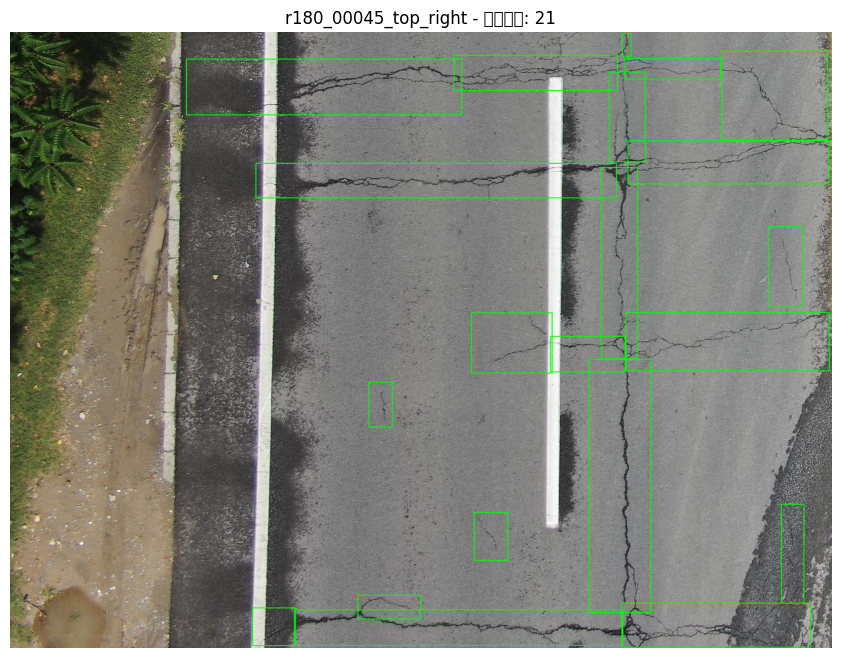

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示问题
DATASET = "/workspace/jupyter_app/lq/two idea/dataset/UAV-PDD2023"
img_dir = os.path.join(DATASET, "images", "train")
lbl_dir = os.path.join(DATASET, "labels", "train")

# 随机选一张有标注的图片
for f in os.listdir(img_dir):
    name = os.path.splitext(f)[0]
    txt_path = os.path.join(lbl_dir, name + '.txt')
    if os.path.exists(txt_path) and os.path.getsize(txt_path) > 0:
        # 读取图片
        img = cv2.imread(os.path.join(img_dir, f))
        h, w = img.shape[:2]
        # 读取标注
        with open(txt_path, 'r') as tf:
            for line in tf:
                cls, xc, yc, bw, bh = map(float, line.strip().split())
                x1 = int((xc - bw/2) * w)
                y1 = int((yc - bh/2) * h)
                x2 = int((xc + bw/2) * w)
                y2 = int((yc + bh/2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        # 显示
        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"{name} - 标注框数: {len(open(txt_path).readlines())}")
        plt.axis('off')
        plt.show()
        break  # 只显示一张

In [6]:
import os
import shutil

# ========== 配置路径 ==========
DATASET_PATH = "/workspace/jupyter_app/lq/two idea/dataset/UAV-PDD2023"
BACKUP_DIR = os.path.join(DATASET_PATH, "_old_split_backup")
# ==============================

# 确保备份目录存在
if not os.path.isdir(BACKUP_DIR):
    raise FileNotFoundError(f"❌ 备份目录不存在: {BACKUP_DIR}")

# 从备份中收集所有图片和标签（原 train + val）
all_pairs = []
for old_split in ['train', 'val']:
    img_bak = os.path.join(BACKUP_DIR, f'images_{old_split}')
    lbl_bak = os.path.join(BACKUP_DIR, f'labels_{old_split}')
    if not os.path.isdir(img_bak) or not os.path.isdir(lbl_bak):
        continue
    for f in os.listdir(img_bak):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            name = os.path.splitext(f)[0]
            txt_path = os.path.join(lbl_bak, name + '.txt')
            if os.path.exists(txt_path):
                all_pairs.append((os.path.join(img_bak, f), txt_path))

print(f"📊 从备份中找到 {len(all_pairs)} 个完整配对")

# 建立文件名到路径的映射（用于根据之前划分的列表查找）
img_map = {os.path.basename(img): img for img, _ in all_pairs}
lbl_map = {os.path.basename(lbl): lbl for _, lbl in all_pairs}

# 之前划分生成的列表（在内存中应该还存在），如果丢失可重新生成，但此处假设仍存在
# 如果变量 train_imgs 等不存在，则从备份中重新随机划分
try:
    # 检查变量是否存在
    train_imgs
except NameError:
    print("⚠️ 未找到之前的划分列表，将重新按 7:2:1 随机划分")
    import random
    from sklearn.model_selection import train_test_split
    all_img_paths = [img for img, _ in all_pairs]
    all_lbl_paths = [lbl for _, lbl in all_pairs]
    train_imgs, temp_imgs, train_lbls, temp_lbls = train_test_split(
        all_img_paths, all_lbl_paths, test_size=0.3, random_state=42
    )
    val_imgs, test_imgs, val_lbls, test_lbls = train_test_split(
        temp_imgs, temp_lbls, test_size=1/3, random_state=42
    )
    train_lbls = train_lbls  # 变量重命名保持一致
else:
    # 使用已有列表，但需要将旧路径转换为备份中的路径
    def convert_to_backup_paths(name_list):
        imgs = []
        lbls = []
        for img_path in name_list:
            fname = os.path.basename(img_path)
            if fname in img_map:
                imgs.append(img_map[fname])
                base = os.path.splitext(fname)[0]
                lbl_fname = base + '.txt'
                if lbl_fname in lbl_map:
                    lbls.append(lbl_map[lbl_fname])
                else:
                    print(f"⚠️ 找不到标签: {lbl_fname}")
            else:
                print(f"⚠️ 找不到图片: {fname}")
        return imgs, lbls

    train_imgs, train_lbls = convert_to_backup_paths(train_imgs)
    val_imgs, val_lbls = convert_to_backup_paths(val_imgs)
    test_imgs, test_lbls = convert_to_backup_paths(test_imgs)

# 创建目标目录（如果不存在）
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(DATASET_PATH, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(DATASET_PATH, 'labels', split), exist_ok=True)

# 复制文件（使用 copy2 保留元数据，若空间紧张可改为 move）
def copy_pairs(img_list, lbl_list, split):
    for src_img, src_lbl in zip(img_list, lbl_list):
        dst_img = os.path.join(DATASET_PATH, 'images', split, os.path.basename(src_img))
        dst_lbl = os.path.join(DATASET_PATH, 'labels', split, os.path.basename(src_lbl))
        shutil.copy2(src_img, dst_img)
        shutil.copy2(src_lbl, dst_lbl)

print("🔄 复制训练集...")
copy_pairs(train_imgs, train_lbls, 'train')
print("🔄 复制验证集...")
copy_pairs(val_imgs, val_lbls, 'val')
print("🔄 复制测试集...")
copy_pairs(test_imgs, test_lbls, 'test')

# 更新 data.yaml（确保有 test 路径）
yaml_path = os.path.join(DATASET_PATH, 'data.yaml')
with open(yaml_path, 'r') as f:
    content = f.read()
if 'test:' not in content:
    with open(yaml_path, 'a') as f:
        f.write('test: images/test\n')
    print("✅ data.yaml 已添加 test 路径")

# 验证
print("\n🔬 验证新划分:")
for split in ['train', 'val', 'test']:
    img_dir = os.path.join(DATASET_PATH, 'images', split)
    lbl_dir = os.path.join(DATASET_PATH, 'labels', split)
    img_cnt = len([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])
    lbl_cnt = len([f for f in os.listdir(lbl_dir) if f.endswith('.txt')])
    print(f"  {split}: 图片 {img_cnt} 张, 标签 {lbl_cnt} 个")

print(f"\n🎉 修复完成！数据集位于: {DATASET_PATH}")
print("💡 您现在可以删除备份目录以释放空间（可选）：")
print(f"   !rm -rf {BACKUP_DIR}")

📊 从备份中找到 2440 个完整配对
🔄 复制训练集...
🔄 复制验证集...
🔄 复制测试集...
✅ data.yaml 已添加 test 路径

🔬 验证新划分:
  train: 图片 1707 张, 标签 1707 个
  val: 图片 489 张, 标签 489 个
  test: 图片 244 张, 标签 244 个

🎉 修复完成！数据集位于: /workspace/jupyter_app/lq/two idea/dataset/UAV-PDD2023
💡 您现在可以删除备份目录以释放空间（可选）：
   !rm -rf /workspace/jupyter_app/lq/two idea/dataset/UAV-PDD2023/_old_split_backup


In [7]:
import os

DATASET_PATH = "/workspace/jupyter_app/lq/two idea/dataset/UAV-PDD2023"

total_boxes = 0
for split in ['train', 'val', 'test']:
    lbl_dir = os.path.join(DATASET_PATH, 'labels', split)
    if not os.path.isdir(lbl_dir):
        continue
    split_boxes = 0
    for f in os.listdir(lbl_dir):
        if f.endswith('.txt'):
            with open(os.path.join(lbl_dir, f), 'r') as ff:
                count = sum(1 for _ in ff)
                split_boxes += count
    print(f"{split}: {split_boxes} 个标注框")
    total_boxes += split_boxes

print(f"\n📦 总标注框数: {total_boxes} 个 (应为 11158)")

train: 7709 个标注框
val: 2254 个标注框
test: 1195 个标注框

📦 总标注框数: 11158 个 (应为 11158)


In [8]:
import os
from collections import defaultdict

DATASET_PATH = "/workspace/jupyter_app/lq/two idea/dataset/UAV-PDD2023"

# 类别名称（与 data.yaml 顺序一致）
class_names = [
    'Alligator crack',   # 0
    'Longitudinal crack',# 1
    'Oblique crack',     # 2
    'Pothole',           # 3
    'Repair',            # 4
    'Transverse crack'   # 5
]

# 统计每个类别在各个子集中的实例数
split_stats = {}
total_per_class = defaultdict(int)

for split in ['train', 'val', 'test']:
    lbl_dir = os.path.join(DATASET_PATH, 'labels', split)
    if not os.path.isdir(lbl_dir):
        continue
    class_count = defaultdict(int)
    img_count = 0
    total_boxes = 0
    for f in os.listdir(lbl_dir):
        if not f.endswith('.txt'):
            continue
        img_count += 1
        with open(os.path.join(lbl_dir, f), 'r') as ff:
            lines = ff.readlines()
            total_boxes += len(lines)
            for line in lines:
                parts = line.strip().split()
                if parts:
                    cls_id = int(parts[0])
                    class_count[cls_id] += 1
                    total_per_class[cls_id] += 1
    split_stats[split] = {
        'images': img_count,
        'boxes': total_boxes,
        'class_counts': class_count
    }

# 打印报告
print("="*60)
print("📊 UAV-PDD2023 数据集类别分布报告")
print("="*60)

for split, stats in split_stats.items():
    print(f"\n🔹 {split.upper()} 集:")
    print(f"  图片数: {stats['images']}")
    print(f"  标注框总数: {stats['boxes']}")
    print("  各类别框数:")
    for cls_id, name in enumerate(class_names):
        count = stats['class_counts'].get(cls_id, 0)
        percentage = (count / stats['boxes'] * 100) if stats['boxes'] > 0 else 0
        print(f"    {cls_id}: {name:20s} -> {count:4d} 个 ({percentage:5.2f}%)")

print("\n" + "="*60)
print("📌 全数据集总计（train + val + test）:")
print(f"  总图片数: {sum(stats['images'] for stats in split_stats.values())}")
print(f"  总标注框数: {sum(stats['boxes'] for stats in split_stats.values())}")
print("  各类别总框数:")
for cls_id, name in enumerate(class_names):
    count = total_per_class.get(cls_id, 0)
    total_boxes_all = sum(stats['boxes'] for stats in split_stats.values())
    percentage = (count / total_boxes_all * 100) if total_boxes_all > 0 else 0
    print(f"    {cls_id}: {name:20s} -> {count:4d} 个 ({percentage:5.2f}%)")

# 检查是否符合论文描述
official_total = 11158
total_boxes = sum(stats['boxes'] for stats in split_stats.values())
if total_boxes == official_total:
    print(f"\n✅ 总标注框数 {total_boxes} 与官方 {official_total} 完全一致。")
else:
    print(f"\n⚠️ 总标注框数 {total_boxes} 与官方 {official_total} 不一致，请检查转换过程。")

# 检查类别是否完整
if set(total_per_class.keys()) == set(range(len(class_names))):
    print("✅ 所有 6 个类别均有标注实例。")
else:
    missing = [class_names[i] for i in range(len(class_names)) if i not in total_per_class]
    print(f"⚠️ 缺少类别: {missing}")

# 评估类别平衡性（简单判断）
print("\n📈 类别平衡性分析:")
counts = [total_per_class.get(i, 0) for i in range(len(class_names))]
if counts:
    max_c = max(counts)
    min_c = min(counts)
    ratio = max_c / min_c if min_c > 0 else float('inf')
    print(f"  最多类别框数: {max_c}, 最少类别框数: {min_c}, 比值: {ratio:.2f}")
    if ratio < 3:
        print("  ✅ 各类别相对平衡（最大/最小 < 3），适合直接训练。")
    elif ratio < 5:
        print("  ⚠️ 类别轻度不平衡，建议使用类别加权或数据增强。")
    else:
        print("  ❌ 类别严重不平衡，强烈建议采用重采样、Focal Loss 或类别加权。")

print("\n✅ 分析完成。")

📊 UAV-PDD2023 数据集类别分布报告

🔹 TRAIN 集:
  图片数: 1707
  标注框总数: 7709
  各类别框数:
    0: Alligator crack      ->  400 个 ( 5.19%)
    1: Longitudinal crack   -> 2076 个 (26.93%)
    2: Oblique crack        -> 1116 个 (14.48%)
    3: Pothole              ->  132 个 ( 1.71%)
    4: Repair               ->  212 个 ( 2.75%)
    5: Transverse crack     -> 3773 个 (48.94%)

🔹 VAL 集:
  图片数: 489
  标注框总数: 2254
  各类别框数:
    0: Alligator crack      ->  121 个 ( 5.37%)
    1: Longitudinal crack   ->  598 个 (26.53%)
    2: Oblique crack        ->  365 个 (16.19%)
    3: Pothole              ->   46 个 ( 2.04%)
    4: Repair               ->   41 个 ( 1.82%)
    5: Transverse crack     -> 1083 个 (48.05%)

🔹 TEST 集:
  图片数: 244
  标注框总数: 1195
  各类别框数:
    0: Alligator crack      ->   82 个 ( 6.86%)
    1: Longitudinal crack   ->  320 个 (26.78%)
    2: Oblique crack        ->  205 个 (17.15%)
    3: Pothole              ->   17 个 ( 1.42%)
    4: Repair               ->   29 个 ( 2.43%)
    5: Transverse crack     ->  542 个 (45

In [9]:
import os
import cv2
import random
import shutil
import numpy as np
from tqdm import tqdm
import albumentations as A

DATASET_PATH = "/workspace/jupyter_app/lq/two idea/dataset/UAV-PDD2023"
TRAIN_IMG_DIR = os.path.join(DATASET_PATH, 'images', 'train')
TRAIN_LBL_DIR = os.path.join(DATASET_PATH, 'labels', 'train')

# 目标：将这三个少数类提升到每类约 1800~2000 个实例
target_classes = {
    0: 1800,  # Alligator crack (目前 603)
    3: 1800,  # Pothole       (目前 195)   -> 重点提升
    4: 1800   # Repair        (目前 282)
}

# 获取所有图片名（不含扩展）
all_names = [os.path.splitext(f)[0] for f in os.listdir(TRAIN_IMG_DIR) if f.lower().endswith(('.jpg','.png'))]

# 统计每个图片包含哪些类别（用于筛选）
img_to_classes = {}
for name in all_names:
    txt_path = os.path.join(TRAIN_LBL_DIR, name + '.txt')
    if not os.path.exists(txt_path):
        continue
    cls_ids = set()
    with open(txt_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                cls_ids.add(int(parts[0]))
    img_to_classes[name] = cls_ids

print(f"总训练图片数: {len(all_names)}")

# 准备增强管道（只对少数类图片使用，确保标签坐标仍有效）
# 注意：不能使用会改变宽高比或剪裁的增强（除非同步调整标签），此处使用安全变换
augmentation = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.6),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=0.5),
    A.Blur(blur_limit=3, p=0.2),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.3))

# 对每个要增强的类别，寻找包含该类的图片
for target_cls, target_num in target_classes.items():
    cls_name = ['Alligator', 'Pothole', 'Repair'][target_cls if target_cls==0 else (target_cls-2)]
    # 筛选包含该类的图片
    candidate_names = [name for name, cls_set in img_to_classes.items() if target_cls in cls_set]
    print(f"\n🔹 {cls_name} (类 {target_cls}): 原始图片 {len(candidate_names)} 张, 目标总数 {target_num}")

    if not candidate_names:
        continue

    # 需要生成的额外数量
    current_count = len(candidate_names)
    needed = target_num - current_count

    if needed <= 0:
        print(f"  已满足目标，跳过。")
        continue

    # 循环生成增强样本（可重复选取同一张原始图片进行多次增强）
    generated = 0
    for _ in tqdm(range(needed), desc=f"生成 {cls_name}"):
        # 随机选一张包含该类的图片（可能重复）
        src_name = random.choice(candidate_names)
        # 读取图片
        img_path = None
        for ext in ['.jpg', '.jpeg', '.png']:
            candidate = os.path.join(TRAIN_IMG_DIR, src_name + ext)
            if os.path.exists(candidate):
                img_path = candidate
                break
        if img_path is None:
            continue
        image = cv2.imread(img_path)
        if image is None:
            continue

        # 读取标签（只保留该类的标签，防止改变其他类）
        txt_path = os.path.join(TRAIN_LBL_DIR, src_name + '.txt')
        bboxes = []
        class_labels = []
        with open(txt_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cls_id = int(parts[0])
                x, y, w, h = map(float, parts[1:])
                # YOLO格式: [x_center, y_center, width, height]
                bboxes.append([x, y, w, h])
                class_labels.append(cls_id)

        # 增强
        try:
            transformed = augmentation(image=image, bboxes=bboxes, class_labels=class_labels)
            aug_img = transformed['image']
            aug_bboxes = transformed['bboxes']
            aug_labels = transformed['class_labels']
        except Exception as e:
            # 极少数情况可能因裁剪导致bbox失效，跳过
            continue

        # 保存增强后的图片和标签（用新文件名）
        new_name = f"{src_name}_aug_{generated}_{target_cls}"
        # 保存图片（保持原扩展名）
        ext = os.path.splitext(img_path)[1]
        dst_img = os.path.join(TRAIN_IMG_DIR, new_name + ext)
        cv2.imwrite(dst_img, aug_img)

        # 保存标签
        dst_txt = os.path.join(TRAIN_LBL_DIR, new_name + '.txt')
        with open(dst_txt, 'w') as f:
            for bbox, cls_id in zip(aug_bboxes, aug_labels):
                # 裁剪后可能归一化仍有效，保险起见做截断
                x_c, y_c, w_b, h_b = bbox
                x_c = max(0, min(1, x_c))
                y_c = max(0, min(1, y_c))
                w_b = max(0, min(1, w_b))
                h_b = max(0, min(1, h_b))
                f.write(f"{int(cls_id)} {x_c:.6f} {y_c:.6f} {w_b:.6f} {h_b:.6f}\n")
        generated += 1

    print(f"  ✅ 为 {cls_name} 生成了 {generated} 张增强样本")

print("\n🎉 增强过采样完成！请重新运行类别分布统计代码查看新平衡。")

总训练图片数: 1707

🔹 Alligator (类 0): 原始图片 273 张, 目标总数 1800


生成 Alligator: 100%|██████████| 1527/1527 [02:51<00:00,  8.88it/s]


  ✅ 为 Alligator 生成了 1519 张增强样本

🔹 Pothole (类 3): 原始图片 93 张, 目标总数 1800


生成 Pothole: 100%|██████████| 1707/1707 [03:12<00:00,  8.88it/s]


  ✅ 为 Pothole 生成了 1707 张增强样本

🔹 Repair (类 4): 原始图片 134 张, 目标总数 1800


生成 Repair: 100%|██████████| 1666/1666 [03:05<00:00,  8.99it/s]

  ✅ 为 Repair 生成了 1666 张增强样本

🎉 增强过采样完成！请重新运行类别分布统计代码查看新平衡。


In [10]:
import os
from collections import defaultdict

DATASET_PATH = "/workspace/jupyter_app/lq/two idea/dataset/UAV-PDD2023"
TRAIN_LBL_DIR = os.path.join(DATASET_PATH, 'labels', 'train')

class_names = [
    'Alligator crack',   # 0
    'Longitudinal crack',# 1
    'Oblique crack',     # 2
    'Pothole',           # 3
    'Repair',            # 4
    'Transverse crack'   # 5
]

# 统计训练集各类别
class_counts = defaultdict(int)
total_boxes = 0
img_count = 0
empty_count = 0

for f in os.listdir(TRAIN_LBL_DIR):
    if not f.endswith('.txt'):
        continue
    img_count += 1
    with open(os.path.join(TRAIN_LBL_DIR, f), 'r') as ff:
        lines = ff.readlines()
        if not lines:
            empty_count += 1
        total_boxes += len(lines)
        for line in lines:
            parts = line.strip().split()
            if parts:
                cls_id = int(parts[0])
                class_counts[cls_id] += 1

print("="*60)
print("📊 增强后训练集类别分布")
print("="*60)
print(f"📸 训练集图片总数: {img_count} 张")
print(f"📦 训练集标注框总数: {total_boxes} 个")
print(f"📭 空标签文件数: {empty_count} 个")
print("\n各类别框数:")
for cls_id, name in enumerate(class_names):
    count = class_counts.get(cls_id, 0)
    pct = (count / total_boxes * 100) if total_boxes > 0 else 0
    print(f"  {cls_id}: {name:20s} -> {count:5d} 个 ({pct:5.2f}%)")

# 计算平衡性
counts = [class_counts.get(i, 0) for i in range(len(class_names))]
max_c, min_c = max(counts), min(counts) if min(counts) > 0 else 1
print(f"\n📈 最大/最小比值: {max_c} / {min_c} = {max_c/min_c:.2f}")

print("\n" + "="*60)
print("✅ 与增强前对比（全数据集 11158 个框）:")
print("   增强前最大/最小比值: 5398/195 = 27.68")
print(f"   增强后训练集最大/最小比值: {max_c}/{min_c} = {max_c/min_c:.2f}")
if max_c / min_c < 3:
    print("   🎉 平衡性显著改善！属于轻度不平衡，可直接配合 Focal Loss 或类别权重训练。")
else:
    print("   ⚠️ 仍存在不平衡，建议在损失函数中增加类别权重或进一步调整增强倍数。")

📊 增强后训练集类别分布
📸 训练集图片总数: 6599 张
📦 训练集标注框总数: 36944 个
📭 空标签文件数: 17 个

各类别框数:
  0: Alligator crack      ->  3581 个 ( 9.69%)
  1: Longitudinal crack   ->  9192 个 (24.88%)
  2: Oblique crack        ->  5126 个 (13.88%)
  3: Pothole              ->  2722 个 ( 7.37%)
  4: Repair               ->  2905 个 ( 7.86%)
  5: Transverse crack     -> 13418 个 (36.32%)

📈 最大/最小比值: 13418 / 2722 = 4.93

✅ 与增强前对比（全数据集 11158 个框）:
   增强前最大/最小比值: 5398/195 = 27.68
   增强后训练集最大/最小比值: 13418/2722 = 4.93
   ⚠️ 仍存在不平衡，建议在损失函数中增加类别权重或进一步调整增强倍数。


In [11]:
import os
from collections import defaultdict

DATASET_PATH = "/workspace/jupyter_app/lq/two idea/dataset/UAV-PDD2023"

# 类别名称（与 data.yaml 顺序一致）
class_names = [
    'Alligator crack',   # 0
    'Longitudinal crack',# 1
    'Oblique crack',     # 2
    'Pothole',           # 3
    'Repair',            # 4
    'Transverse crack'   # 5
]

# 统计每个类别在各个子集中的实例数
split_stats = {}
total_per_class = defaultdict(int)

for split in ['train', 'val', 'test']:
    lbl_dir = os.path.join(DATASET_PATH, 'labels', split)
    if not os.path.isdir(lbl_dir):
        continue
    class_count = defaultdict(int)
    img_count = 0
    total_boxes = 0
    for f in os.listdir(lbl_dir):
        if not f.endswith('.txt'):
            continue
        img_count += 1
        with open(os.path.join(lbl_dir, f), 'r') as ff:
            lines = ff.readlines()
            total_boxes += len(lines)
            for line in lines:
                parts = line.strip().split()
                if parts:
                    cls_id = int(parts[0])
                    class_count[cls_id] += 1
                    total_per_class[cls_id] += 1
    split_stats[split] = {
        'images': img_count,
        'boxes': total_boxes,
        'class_counts': class_count
    }

# 打印报告
print("="*60)
print("📊 UAV-PDD2023 最新数据集类别分布报告")
print("="*60)

for split, stats in split_stats.items():
    print(f"\n🔹 {split.upper()} 集:")
    print(f"  图片数: {stats['images']}")
    print(f"  标注框总数: {stats['boxes']}")
    print("  各类别框数:")
    for cls_id, name in enumerate(class_names):
        count = stats['class_counts'].get(cls_id, 0)
        percentage = (count / stats['boxes'] * 100) if stats['boxes'] > 0 else 0
        print(f"    {cls_id}: {name:20s} -> {count:4d} 个 ({percentage:5.2f}%)")

print("\n" + "="*60)
print("📌 全数据集总计（train + val + test）:")
print(f"  总图片数: {sum(stats['images'] for stats in split_stats.values())}")
print(f"  总标注框数: {sum(stats['boxes'] for stats in split_stats.values())}")
print("  各类别总框数:")
for cls_id, name in enumerate(class_names):
    count = total_per_class.get(cls_id, 0)
    total_boxes_all = sum(stats['boxes'] for stats in split_stats.values())
    percentage = (count / total_boxes_all * 100) if total_boxes_all > 0 else 0
    print(f"    {cls_id}: {name:20s} -> {count:4d} 个 ({percentage:5.2f}%)")

# 检查是否符合论文描述
official_total = 11158
total_boxes = sum(stats['boxes'] for stats in split_stats.values())
if total_boxes == official_total:
    print(f"\n✅ 总标注框数 {total_boxes} 与官方 {official_total} 完全一致。")
else:
    print(f"\n⚠️ 总标注框数 {total_boxes} 与官方 {official_total} 不一致，请检查转换过程。")

# 检查类别是否完整
if set(total_per_class.keys()) == set(range(len(class_names))):
    print("✅ 所有 6 个类别均有标注实例。")
else:
    missing = [class_names[i] for i in range(len(class_names)) if i not in total_per_class]
    print(f"⚠️ 缺少类别: {missing}")

# 评估类别平衡性（简单判断）
print("\n📈 类别平衡性分析:")
counts = [total_per_class.get(i, 0) for i in range(len(class_names))]
if counts:
    max_c = max(counts)
    min_c = min(counts)
    ratio = max_c / min_c if min_c > 0 else float('inf')
    print(f"  最多类别框数: {max_c}, 最少类别框数: {min_c}, 比值: {ratio:.2f}")
    if ratio < 3:
        print("  ✅ 各类别相对平衡（最大/最小 < 3），适合直接训练。")
    elif ratio < 5:
        print("  ⚠️ 类别轻度不平衡，建议使用类别加权或数据增强。")
    else:
        print("  ❌ 类别严重不平衡，强烈建议采用重采样、Focal Loss 或类别加权。")

print("\n✅ 分析完成。")

📊 UAV-PDD2023 最新数据集类别分布报告

🔹 TRAIN 集:
  图片数: 6599
  标注框总数: 36944
  各类别框数:
    0: Alligator crack      -> 3581 个 ( 9.69%)
    1: Longitudinal crack   -> 9192 个 (24.88%)
    2: Oblique crack        -> 5126 个 (13.88%)
    3: Pothole              -> 2722 个 ( 7.37%)
    4: Repair               -> 2905 个 ( 7.86%)
    5: Transverse crack     -> 13418 个 (36.32%)

🔹 VAL 集:
  图片数: 489
  标注框总数: 2254
  各类别框数:
    0: Alligator crack      ->  121 个 ( 5.37%)
    1: Longitudinal crack   ->  598 个 (26.53%)
    2: Oblique crack        ->  365 个 (16.19%)
    3: Pothole              ->   46 个 ( 2.04%)
    4: Repair               ->   41 个 ( 1.82%)
    5: Transverse crack     -> 1083 个 (48.05%)

🔹 TEST 集:
  图片数: 244
  标注框总数: 1195
  各类别框数:
    0: Alligator crack      ->   82 个 ( 6.86%)
    1: Longitudinal crack   ->  320 个 (26.78%)
    2: Oblique crack        ->  205 个 (17.15%)
    3: Pothole              ->   17 个 ( 1.42%)
    4: Repair               ->   29 个 ( 2.43%)
    5: Transverse crack     ->  542 个